In [1]:
import matplotlib.pyplot as plt
import numpy as np
import numba as nb

$\psi \propto \iint_\Sigma h(x,y)\cos(\theta_P)e^{ikr}dxdy$

$r^2 = L^2+(x-x_0)^2+(y-y_0)^2$

Convention is origin at the center

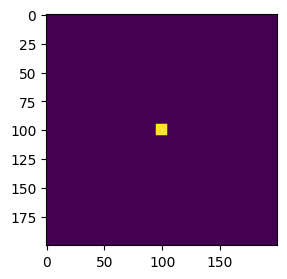

In [ ]:
subplot_width=10
height=10
h_size = 200
h = np.zeros((h_size,h_size),dtype=np.uint8)
for i in range((h_size-subplot_width)//2,(h_size+subplot_width)//2):
    for j in range((h_size-height)//2,(h_size+height)//2):
        h[i,j] = True
plt.figure(figsize=(3,3))
plt.imshow(h)

In [194]:
@nb.njit('float64[:,:](uint8[:,:],int64,float64,float64)',parallel=True, nogil=True)
def compute(h, r_size=100,L=10000, lamb=0.001):
    result = np.zeros((r_size,r_size),dtype=np.complex128)
    k = 2*np.pi/lamb
    L_square = L*L
    half_size = r_size//2
    h_origin = len(h)//2
    offset = h_origin-half_size
    for x0 in range(result.shape[0]):
        for y0 in range(result.shape[1]):
            for x in range(h.shape[0]):
                for y in range(h.shape[1]):
                    pass
                    if h[x,y]:
                        r = ((x0-x+offset)**2+(y0-y+offset)**2+L_square)**.5
                        result[x0,y0] += h[x,y]*np.e**(1j*k*r)/r*(L/r)
    return np.abs(result)
    

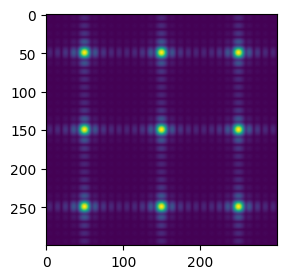

In [195]:
result = compute(h, r_size = 300,L=10000,lamb=0.01)
plt.figure(figsize=(3,3))
plt.imshow(result)

In [75]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [ ]:
def get_anim(total_frames, max_time=10):
    fps = 10.0
    fps = fps if fps>total_frames/max_time else total_frames/max_time
    distances = np.linspace(1,100000,total_frames)
    
    fig = plt.figure(figsize=(3,3))
    im = plt.imshow(compute(h, r_size = 300,L=distances[0],lamb=0.01))
    def animate_func(i):
        result = compute(h, r_size = 300,L=distances[i],lamb=0.01)
        im.set_array(result)
        im.set_clim(np.min(result),np.max(result))
        print(i,end='\r')
        return [im]

    return FuncAnimation(fig,animate_func,frames=total_frames,interval = 1000 / fps)

In [ ]:
HTML(get_anim(total_frames=200).to_jshtml())

In [104]:
from PIL import Image, ImageDraw, ImageFont

In [215]:
letters1 = r'ABCDEFGHIJKLMN'
letters2 = r'OPQRSTUVWXYZ'
letters3 = r'αβγδεζηθικλμ'
letters4 = r'νξοπρστυφχψω'
letters5 = r'上下左右前后'

In [292]:
def create_image(size, bgColor, message, font, fontColor):
    W, H = size
    image = Image.new('L', size, bgColor)
    draw = ImageDraw.Draw(image)
    _, _, w, h = draw.textbbox((0, 0), message, font=font)
    draw.text(((W-w)/2, (H-h)/2), message, font=font, fill=fontColor)
    return image

In [368]:
def plot_letters(letters, resolution=150, fontsize=30, lamb = 0.001, use_log=False):
    fontsize = fontsize
    canvas_size = resolution
    # each row 3 letters, 6 graphs
    subplot_width = 6
    if len(letters)*2%subplot_width==0:
        fig,ax = plt.subplots(len(letters)//subplot_width*2, subplot_width)
        ax = ax.flatten()
    else:
        fig,ax = plt.subplots(len(letters)//subplot_width*2+1, subplot_width)
        ax = ax.flatten()
        for i in range(subplot_width - (len(letters)*2)%subplot_width):
            fig.delaxes(ax[-i-1])
    
    for i in range(len(letters)):
        fnt = ImageFont.truetype(r"C:\Windows\Fonts\msyhbd.ttc", fontsize)
        img = create_image((canvas_size,canvas_size), 0, letters[i], fnt, 1)
        h_letter = np.array(img,dtype=np.uint8)
        ax[(2*i)//subplot_width*subplot_width  +  (2*i)%subplot_width].imshow(h_letter)
        if use_log:
            ax[(2*i+1)//subplot_width*subplot_width  +  (2*i+1)%subplot_width].imshow(np.log(compute(h_letter, r_size=canvas_size,L=100000,lamb=lamb)))
        else:
            ax[(2*i+1)//subplot_width*subplot_width  +  (2*i+1)%subplot_width].imshow(compute(h_letter, r_size=canvas_size,L=100000,lamb=lamb))
    return fig,ax

In [337]:
%%capture
fig,ax = plot_letters(letters5,50,10)

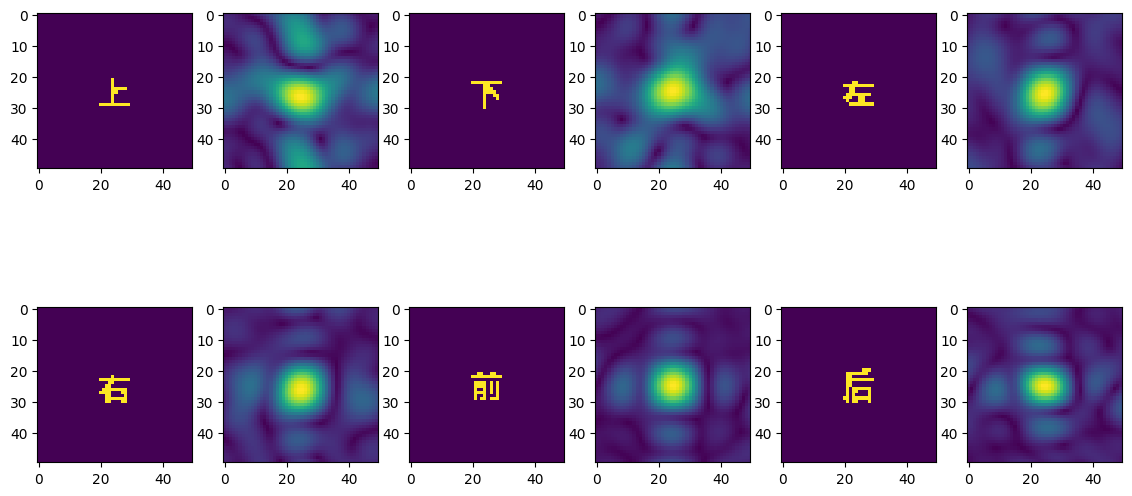

In [338]:
fig.set_figwidth(14)
fig.set_figheight(7)
fig

In [342]:
%%capture
fig,ax = plot_letters(letters3+letters4,100,20)

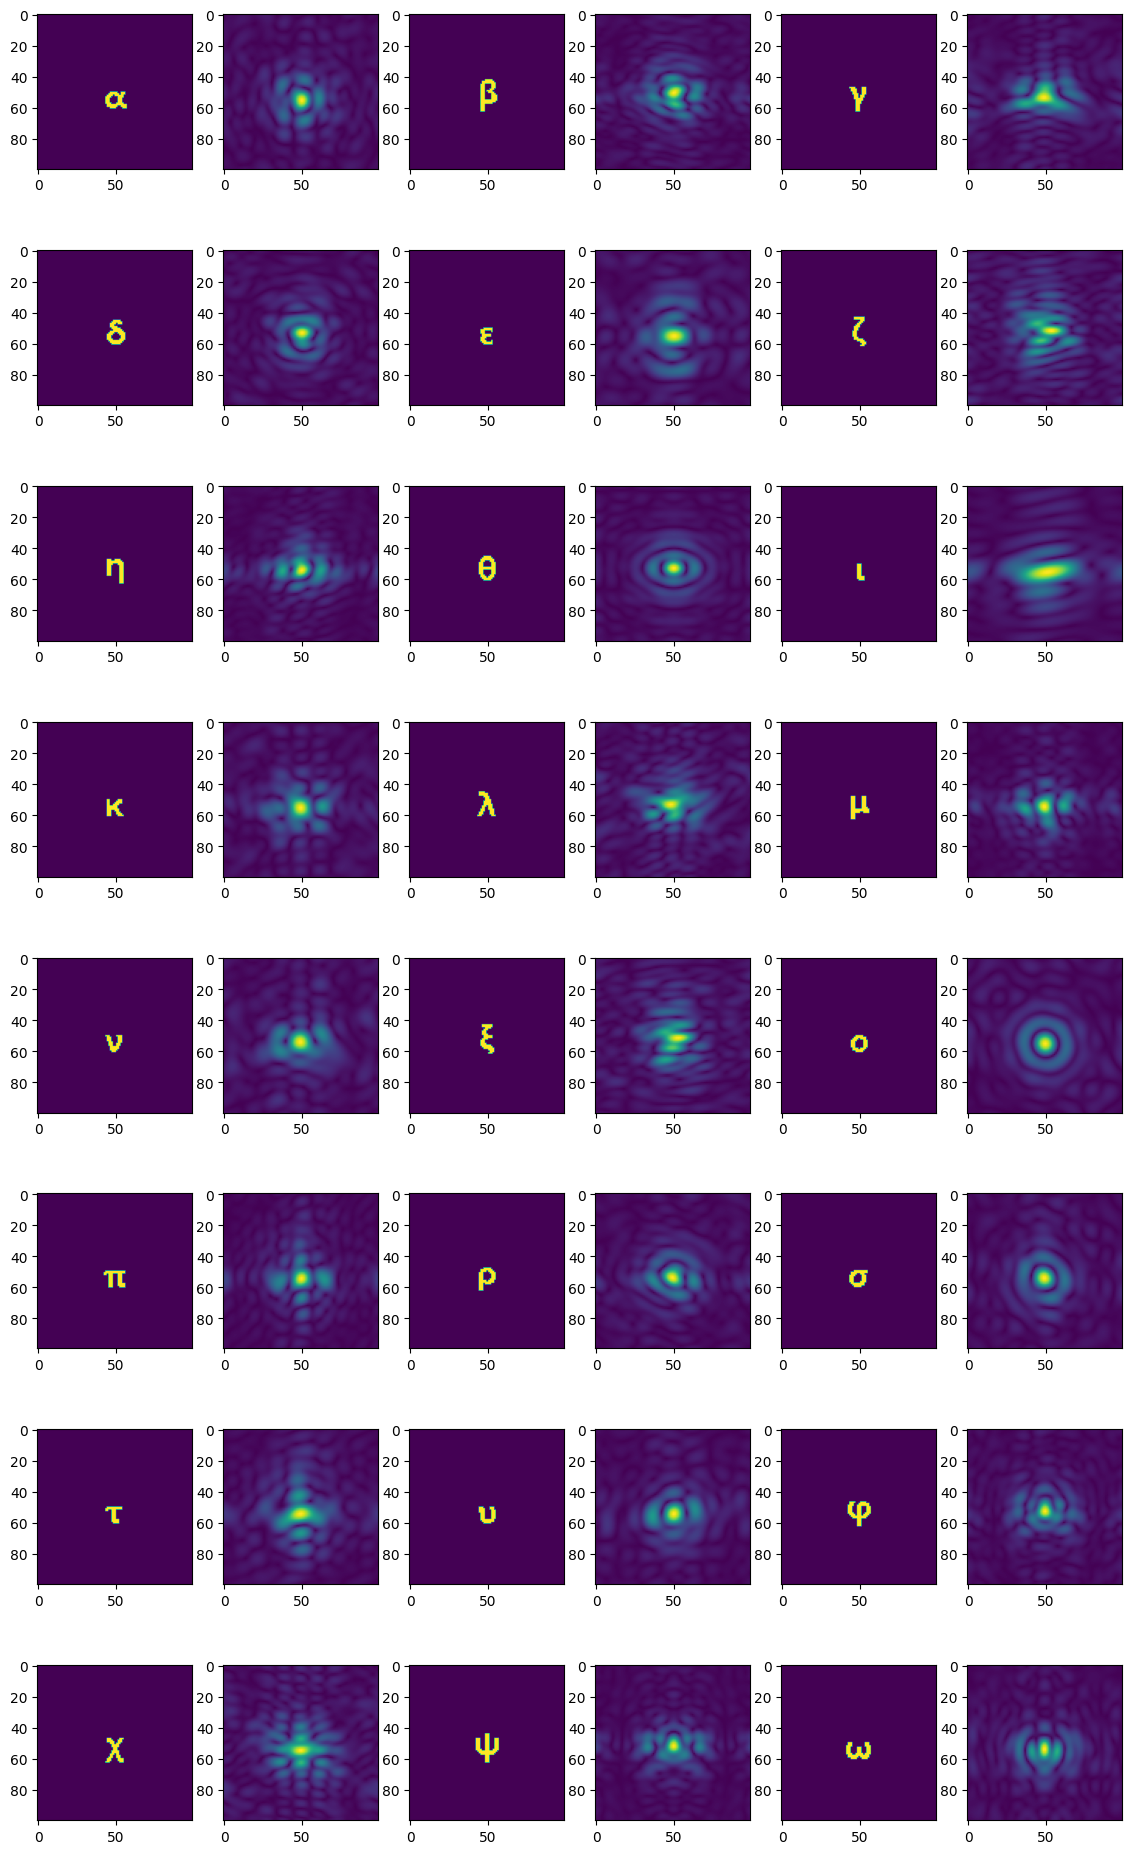

In [343]:
fig.set_figwidth(14)
fig.set_figheight(24)
fig

In [344]:
%%capture
fig,ax = plot_letters(letters1+letters2,300,60)

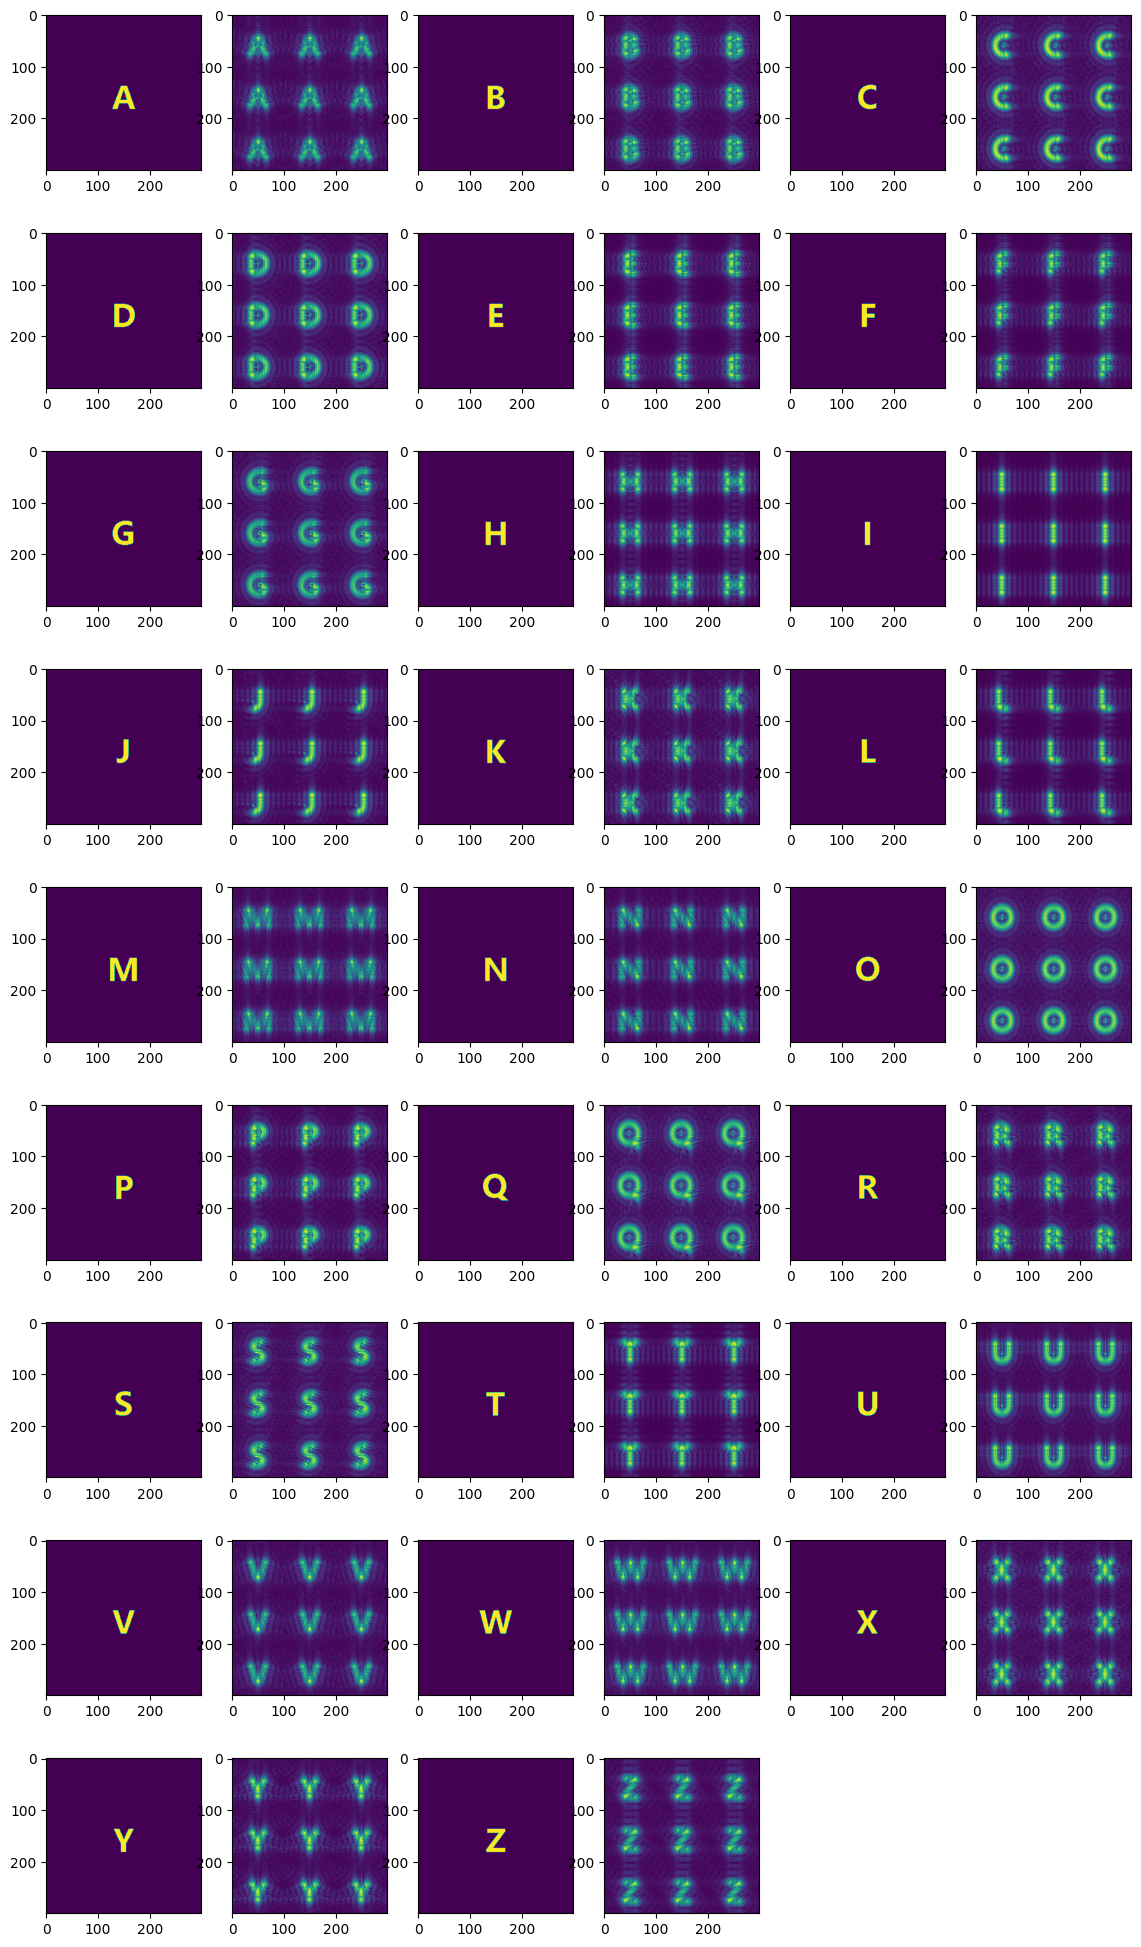

In [345]:
fig.set_figwidth(14)
fig.set_figheight(25)
fig

In [377]:
%%capture
fig,ax = plot_letters(letters1+letters2,250,50, lamb = 0.005)

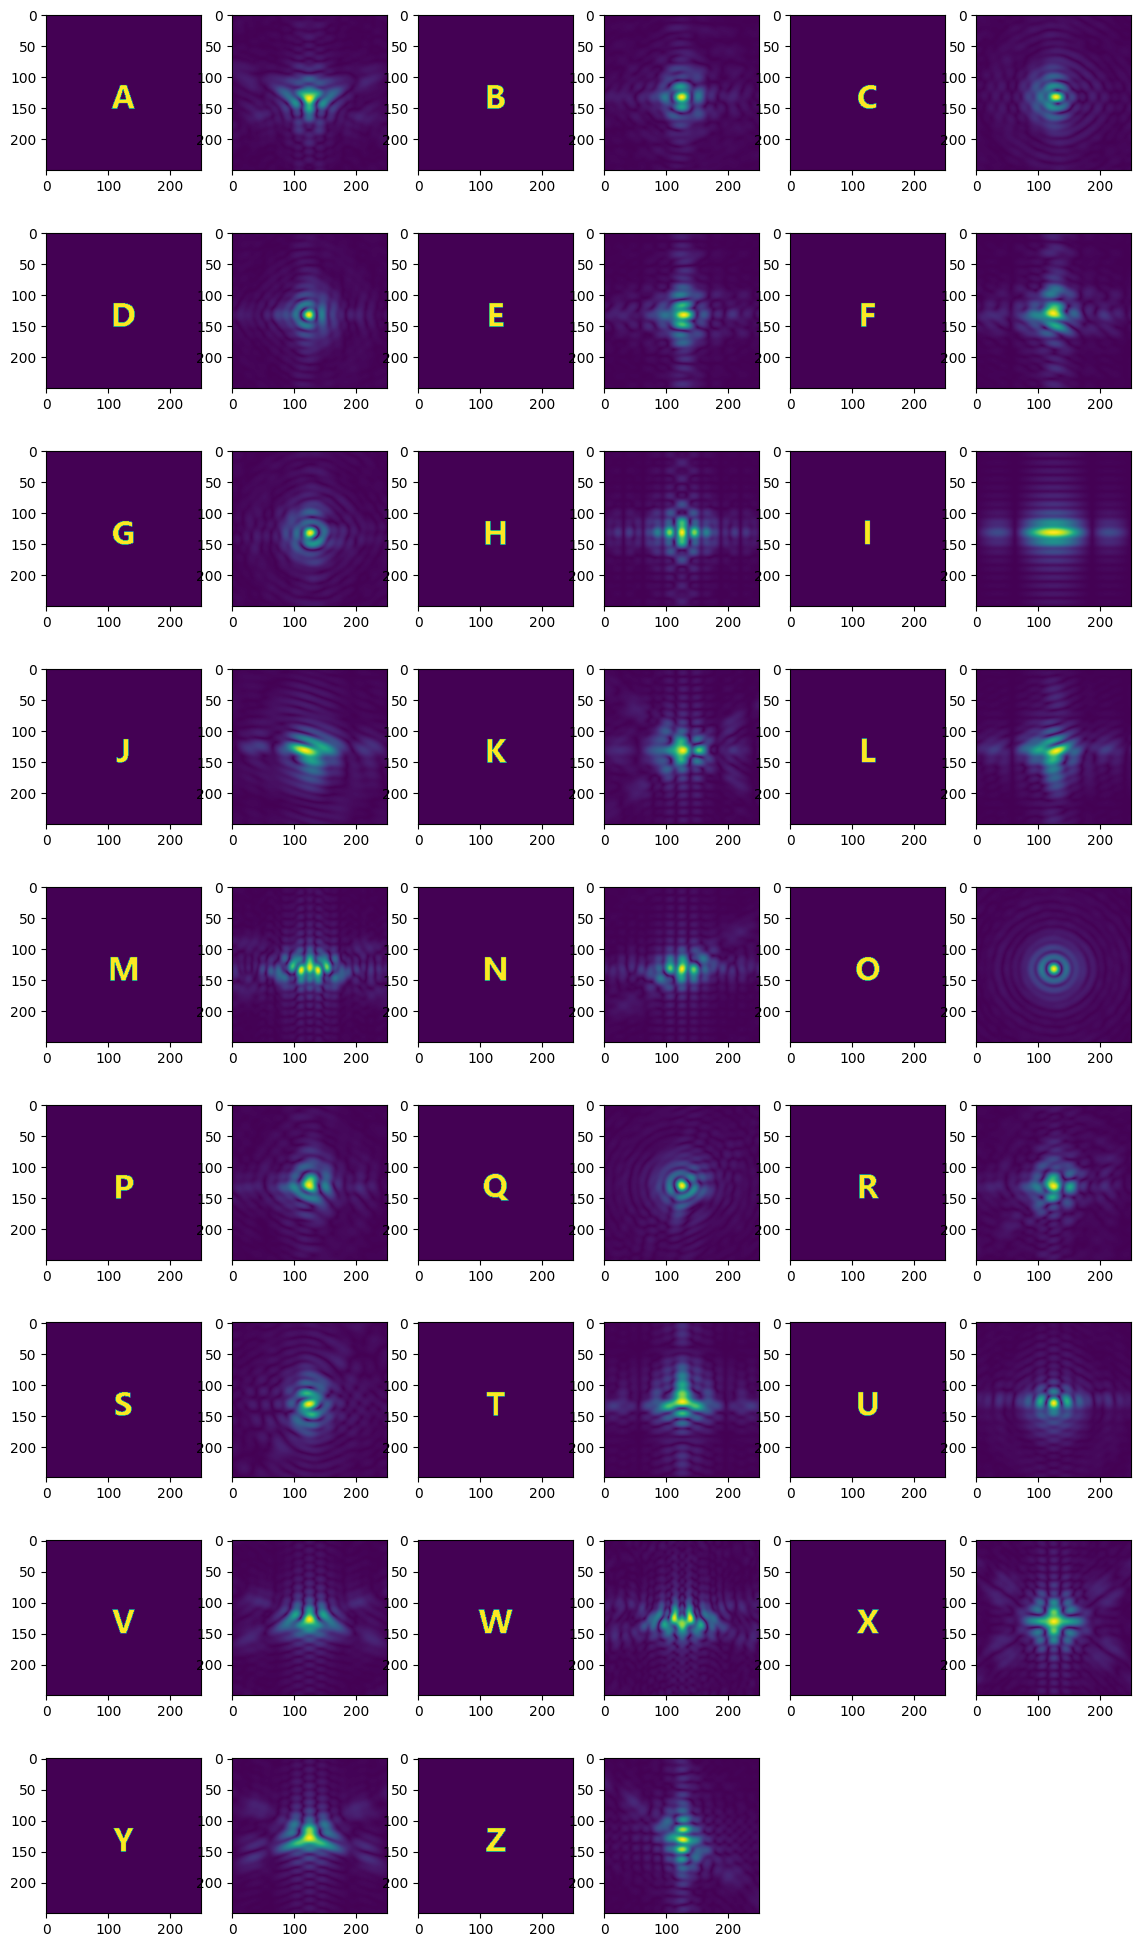

In [378]:
fig.set_figwidth(14)
fig.set_figheight(25)
fig